In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #better looking graph
from pathlib import Path

In [2]:
from pathlib import Path
data_path = Path("../data/raw/training_setA")
patient_files = list(data_path.glob("*.psv")) #searches inside the data_path with reference of .psv
print(f"Number of patient files: {len(patient_files)}")
for file in patient_files[:5]:
    patient = pd.read_csv(file, sep="|")
    print(file.name, patient.shape)


Number of patient files: 20336
p000001.psv (54, 41)
p000002.psv (23, 41)
p000003.psv (48, 41)
p000004.psv (29, 41)
p000005.psv (48, 41)


In [3]:
sepsis_patients = 0
non_sepsis_patients = 0

for file in patient_files:

    patient = pd.read_csv(file, sep="|")

    if patient["SepsisLabel"].max() == 1:
        sepsis_patients += 1
    else:
        non_sepsis_patients += 1

print("Sepsis Patients:", sepsis_patients)
print("Non-Sepsis Patients:", non_sepsis_patients)
total_patients = sepsis_patients + non_sepsis_patients
sepsis_percentage = (sepsis_patients/ total_patients)*100
non_sepsis_percentage = (non_sepsis_patients/total_patients)*100
print("total number of patients:", total_patients)
print("'percentage of sepsis in percentage:", sepsis_percentage)
print("percentage of non sepsis in percentage :" , non_sepsis_percentage)

Sepsis Patients: 1790
Non-Sepsis Patients: 18546
total number of patients: 20336
'percentage of sepsis in percentage: 8.802124311565697
percentage of non sepsis in percentage : 91.19787568843431


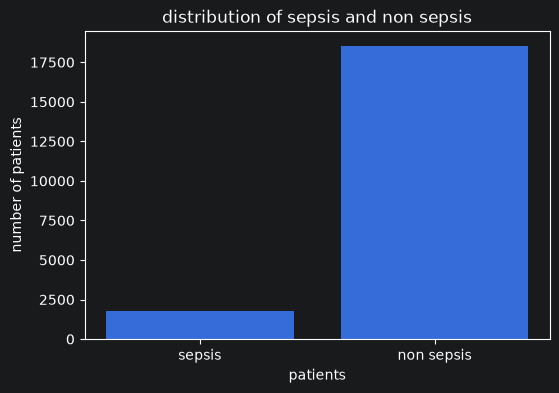

In [4]:
labels = ["sepsis" , "non sepsis"]
counts = [sepsis_patients, non_sepsis_patients]
plt.figure(figsize=(6,4))
plt.bar(labels,counts)
plt.title("distribution of sepsis and non sepsis")
plt.xlabel("patients")
plt.ylabel("number of patients")
plt.show()

In [5]:
pd
patient_files

[WindowsPath('../data/raw/training_setA/p000001.psv'),
 WindowsPath('../data/raw/training_setA/p000002.psv'),
 WindowsPath('../data/raw/training_setA/p000003.psv'),
 WindowsPath('../data/raw/training_setA/p000004.psv'),
 WindowsPath('../data/raw/training_setA/p000005.psv'),
 WindowsPath('../data/raw/training_setA/p000006.psv'),
 WindowsPath('../data/raw/training_setA/p000007.psv'),
 WindowsPath('../data/raw/training_setA/p000008.psv'),
 WindowsPath('../data/raw/training_setA/p000009.psv'),
 WindowsPath('../data/raw/training_setA/p000010.psv'),
 WindowsPath('../data/raw/training_setA/p000011.psv'),
 WindowsPath('../data/raw/training_setA/p000012.psv'),
 WindowsPath('../data/raw/training_setA/p000013.psv'),
 WindowsPath('../data/raw/training_setA/p000014.psv'),
 WindowsPath('../data/raw/training_setA/p000015.psv'),
 WindowsPath('../data/raw/training_setA/p000016.psv'),
 WindowsPath('../data/raw/training_setA/p000017.psv'),
 WindowsPath('../data/raw/training_setA/p000018.psv'),
 WindowsPa

In [6]:
all_patients = []

for file in patient_files:
    patient = pd.read_csv(file, sep="|")
    all_patients.append(patient)

all_data = pd.concat(all_patients, ignore_index=True)

print(all_data.shape)

(790215, 41)


In [7]:
missing_values = all_data.isnull().sum() #this code will find the missing value NAN by going through the dataset then the NAN all are added up this adding is done by sum()

missing_percentage = (missing_values / len(all_data)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table.head(10)


,Missing Values,Missing Percentage
EtCO2,790215,100.000000
TroponinI,789250,99.877881
Bilirubin_direct,789033,99.850420
Fibrinogen,784185,99.236917
Bilirubin_total,780522,98.773372
Alkalinephos,778683,98.540650
AST,778395,98.504205
Lactate,763072,96.565112
PTT,751909,95.152459
SaO2,751055,95.044387


In [ ]:
# END OF EDA EXPLORATORY DATA ANALYSIS

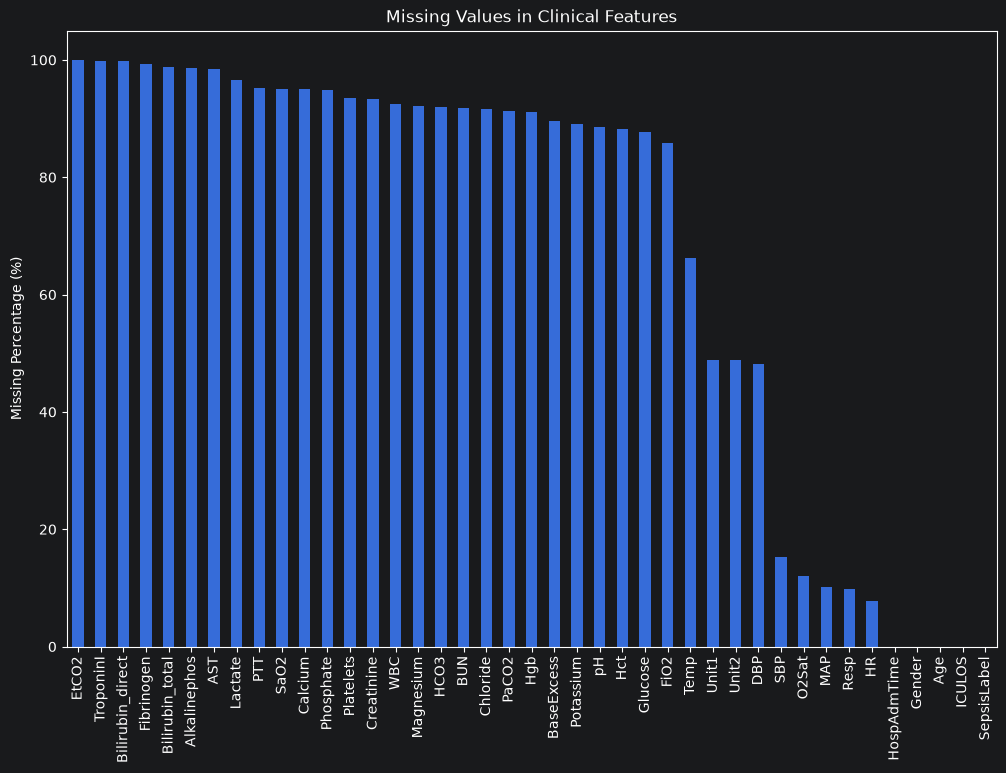

In [17]:
missing_table = pd.DataFrame({
    "Missing Count": all_data.isnull().sum(),
    "Missing Percentage": (all_data.isnull().mean() * 100)
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table
plt.figure(figsize=(12,8))

missing_table["Missing Percentage"].plot(kind="bar")

plt.ylabel("Missing Percentage (%)")
plt.title("Missing Values in Clinical Features")

plt.show()
# in this graph the right most part is the known information like name age sepsis label so on but on the other side the left part the percentage is high in which we can understand the missing value is due lack of consistent test eg troponin bilirubin fibrinogen 